Generating anisotropic data...
Training Gaussian Mixture Model...
AIC: 1596.92
BIC: 1664.77
Silhouette Score: 0.4752


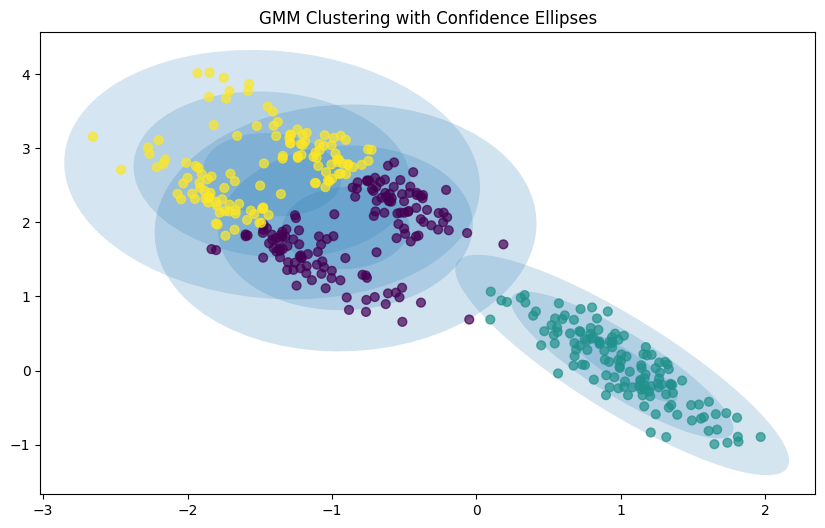

In [1]:


import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

# --- 1. Data Generation ---
# Generate stretched data to demonstrate GMM superiority over K-Means for non-spherical blobs
print("Generating anisotropic data...")
X, y_true = make_blobs(n_samples=400, centers=3, cluster_std=0.60, random_state=0)
rng = np.random.RandomState(13)
X_stretched = np.dot(X, rng.randn(2, 2))

# --- 2. Model Training ---
# n_components is the number of clusters
print("Training Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_stretched)
labels = gmm.predict(X_stretched)

# Probabilistic soft clustering (probability of belonging to each cluster)
probs = gmm.predict_proba(X_stretched)

# --- 3. Evaluation ---
# AIC/BIC are traditional model selection criteria for GMM (lower is better)
print(f"AIC: {gmm.aic(X_stretched):.2f}")
print(f"BIC: {gmm.bic(X_stretched):.2f}")
print(f"Silhouette Score: {silhouette_score(X_stretched, labels):.4f}")

# --- 4. Visualization ---
from matplotlib.patches import Ellipse

def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_stretched[:, 0], X_stretched[:, 1], c=labels, s=40, cmap='viridis', zorder=2, alpha=0.7)

w_factor = 0.2 / gmm.weights_.max()
for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
    draw_ellipse(pos, covar, alpha=w * w_factor)

ax.set_title("GMM Clustering with Confidence Ellipses")
plt.show()